<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L04-Transform_Suavizamiento/notebooks/L04_2_Suavizamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# **Suavizamiento Exponencial**

In [2]:
# Subir archivo motororg.dat
from google.colab import files
files.upload()

Saving motororg.dat to motororg.dat


{'motororg.dat': b'complaints\n27\n34\n31\n24\n18\n19\n17\n12\n26\n14\n18\n33\n31\n31\n19\n17\n10\n25\n26\n18\n18\n10\n4\n20\n28\n21\n18\n23\n19\n16\n10\n24\n11\n11\n13\n27\n18\n20\n21\n6\n9\n29\n12\n19\n14\n19\n16\n23\n\n'}

In [3]:
# Leer el archivo motororg.dat
df = pd.read_csv('/content/motororg.dat', header=0) # Usar indice 0 como encabezado
df.head()

,complaints
0,27
1,34
2,31
3,24
4,18


In [4]:
df['Fecha'] = pd.period_range(start='1996-01', periods=len(df), freq='M')
df = df.set_index('Fecha')
df.index = df.index.to_timestamp()
df.head()

,complaints
Fecha,
1996-01-01,27
1996-02-01,34
1996-03-01,31
1996-04-01,24
1996-05-01,18


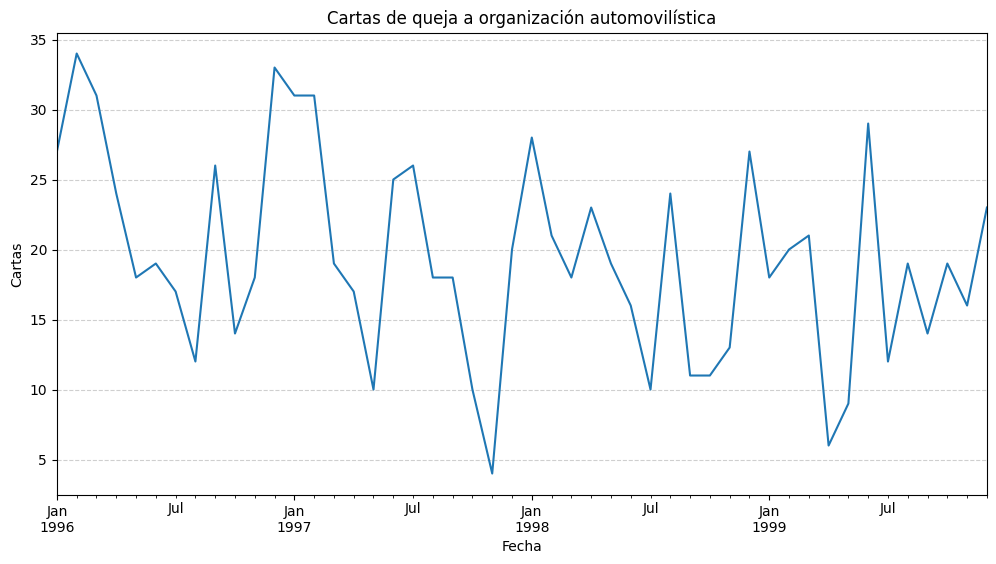

In [5]:
columna = 'complaints'

# Gráfico inicial
plt.figure(figsize=(12, 6))
df[columna].plot()

# Etiquetas
plt.title('Cartas de queja a organización automovilística')
plt.xlabel('Fecha')
plt.ylabel('Cartas')

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [6]:
# Aplicar suavizamiento exponencial con alpha = 0.1
fit1 = ExponentialSmoothing(df['complaints'],
                            seasonal_periods=12
                            ).fit(
                            smoothing_level=0.1
                            )
df['smooth_alpha_0.1'] = fit1.fittedvalues
df.head()

,complaints,smooth_alpha_0.1
Fecha,,
1996-01-01,27,22.850292
1996-02-01,34,23.265262
1996-03-01,31,24.338736
1996-04-01,24,25.004863
1996-05-01,18,24.904376


In [7]:
# Aplicar suavizamiento exponencial con alpha = 0.7
fit2 = ExponentialSmoothing(df['complaints'],
                            seasonal_periods=12
                            ).fit(
                            smoothing_level=0.7
                            )
df['smooth_alpha_0.7'] = fit2.fittedvalues
df.head()

,complaints,smooth_alpha_0.1,smooth_alpha_0.7
Fecha,,,
1996-01-01,27,22.850292,28.592986
1996-02-01,34,23.265262,27.477896
1996-03-01,31,24.338736,32.043369
1996-04-01,24,25.004863,31.313011
1996-05-01,18,24.904376,26.193903


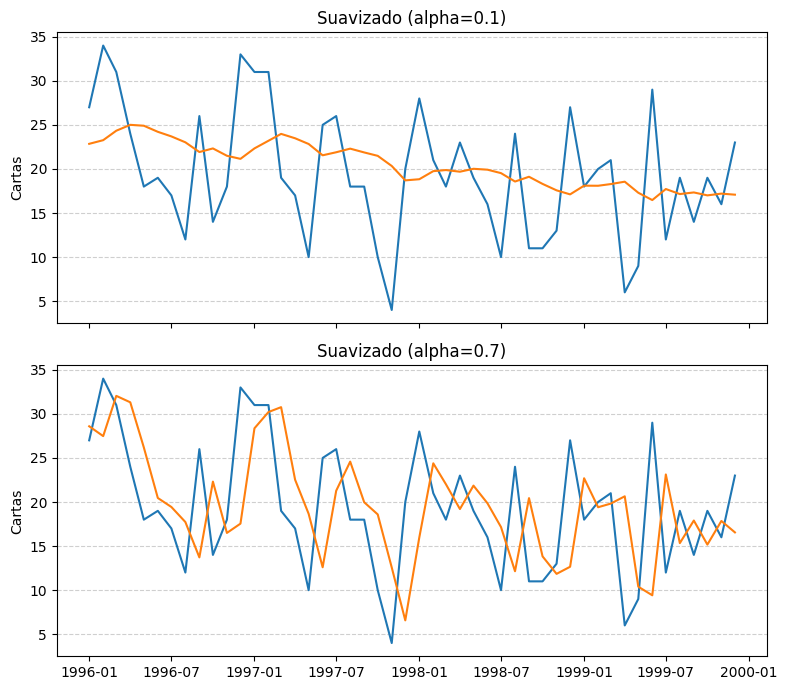

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Gráfico superior: Mucho Suavizamiento
ax[0].plot(df.index, df['complaints'], label='Original')
ax[0].plot(df.index, df['smooth_alpha_0.1'], label='Suavizado (alpha=0.1)')
ax[0].set_title('Suavizado (alpha=0.1)')
ax[0].set_ylabel('Cartas')
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico inferior: Poco Suavizamiento
ax[1].plot(df.index, df['complaints'], label='Original')
ax[1].plot(df.index, df['smooth_alpha_0.7'], label='Suavizado (alpha=0.7)')
ax[1].set_title('Suavizado (alpha=0.7)')
ax[1].set_ylabel('Cartas')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()